<h1>Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unittest
import numpy.testing as npt
from typing import Tuple, Dict, Optional, Union, List

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [2]:
def sum_prod(X, V):
    X = np.asarray(X)
    V = np.asarray(V)

    if V.ndim == 2:
        V = V[..., np.newaxis]

    products = X @ V

    return np.sum(products, axis=0)

In [3]:
class TestSumProd(unittest.TestCase):
    def test_result_shape_consistency(self):
        p, n = 4, 5
        np.random.seed(1)
        X = np.random.rand(p, n, n)
        V_base = np.random.rand(p, n)
        V_2d = V_base.copy()
        V_3d = V_base.reshape(p, n, 1)

        res_2d = sum_prod(X, V_2d)
        res_3d = sum_prod(X, V_3d)

        self.assertEqual(res_2d.shape, (n, 1))
        self.assertEqual(res_3d.shape, (n, 1))
        np.testing.assert_allclose(res_2d, res_3d, rtol=1e-7)

    def test_basic_case_known_values(self):
        X = [np.array([[1, 0], [0, 1]]), np.array([[2, 0], [0, 2]])]
        V = [np.array([[1], [2]]), np.array([[3], [4]])]
        res = sum_prod(X, V)
        np.testing.assert_array_equal(res, np.array([[7], [10]]))

    def test_single_matrix_vector(self):
        X = [np.array([[1, 2], [3, 4]])]
        V = [np.array([[5], [6]])]
        res = sum_prod(X, V)
        np.testing.assert_array_equal(res, np.array([[17], [39]]))

    def test_numpy_arrays_input(self):
        X = np.array([[[1, 0], [0, 1]], [[0, 1], [1, 0]]])
        V = np.array([[[2], [3]], [[4], [5]]])
        res = sum_prod(X, V)
        np.testing.assert_array_equal(res, np.array([[7], [7]]))

    def test_n_equals_one(self):
        X = np.array([[[2]], [[3]]])
        V = np.array([[[4]], [[5]]])
        res = sum_prod(X, V)
        np.testing.assert_array_equal(res, np.array([[23]]))

    def test_random_large_vectorized_vs_loop(self):
        np.random.seed(42)
        p, n = 10, 50
        X = np.random.randn(p, n, n)
        V = np.random.randn(p, n, 1)
        
        res_vectorized = sum_prod(X, V)
        res_loop = sum(X[i] @ V[i] for i in range(p))
        
        np.testing.assert_allclose(res_vectorized, res_loop, rtol=1e-5)

    def test_invalid_shapes(self):
        with self.assertRaises(ValueError):
            X = np.array([[[1, 2], [3, 4]]])
            V = np.array([[[1], [2], [3]]])
            sum_prod(X, V)

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_basic_case_known_values (__main__.TestSumProd.test_basic_case_known_values) ... ok
test_invalid_shapes (__main__.TestSumProd.test_invalid_shapes) ... ok
test_n_equals_one (__main__.TestSumProd.test_n_equals_one) ... ok
test_numpy_arrays_input (__main__.TestSumProd.test_numpy_arrays_input) ... ok
test_random_large_vectorized_vs_loop (__main__.TestSumProd.test_random_large_vectorized_vs_loop) ... ok
test_result_shape_consistency (__main__.TestSumProd.test_result_shape_consistency) ... ok
test_single_matrix_vector (__main__.TestSumProd.test_single_matrix_vector) ... ok

----------------------------------------------------------------------
Ran 7 tests in 0.025s

OK


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [4]:
def binarize(M, threshold=0.5):
    M = np.asarray(M)
    return (M > threshold).astype(int)

In [5]:
class TestBinarize(unittest.TestCase):
    def test_default_threshold_2d(self):
        M = np.array([[0.1, 0.6], 
                      [0.8, 0.4]])
        expected = np.array([[0, 1], 
                             [1, 0]])
        npt.assert_array_equal(binarize(M), expected)

    def test_custom_threshold(self):
        M = np.array([[1, 2, 3], 
                      [4, 5, 6]])
        expected = np.array([[0, 0, 1], 
                             [1, 1, 1]])
        npt.assert_array_equal(binarize(M, threshold=2.5), expected)

    def test_boundary_condition_equal_to_threshold(self):
        M = np.array([0.5, 0.50000001, 0.49999999])
        expected = np.array([0, 1, 0])
        npt.assert_array_equal(binarize(M), expected)

    def test_all_above_threshold(self):
        M = np.array([[10, 20], [30, 40]])
        expected = np.ones((2, 2), dtype=int)
        npt.assert_array_equal(binarize(M, threshold=5), expected)

    def test_all_below_or_equal_threshold(self):
        M = np.array([[0.1, 0.5], [0.0, 0.5]])
        expected = np.zeros((2, 2), dtype=int)
        npt.assert_array_equal(binarize(M, threshold=0.5), expected)

    def test_empty_matrix(self):
        M = np.array([])
        npt.assert_array_equal(binarize(M), np.array([], dtype=int))

    def test_list_of_lists_input(self):
        M = [[0.2, 0.9], [0.9, 0.2]]
        expected = np.array([[0, 1], [1, 0]], dtype=int)
        npt.assert_array_equal(binarize(M), expected)

    def test_preserves_shape(self):
        M = np.random.rand(3, 4, 2)
        result = binarize(M, threshold=0.7)
        self.assertEqual(result.shape, M.shape)

    def test_invalid_input_type(self):
        with self.assertRaises((TypeError, ValueError)):
            binarize("not_a_matrix")

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
test_all_below_or_equal_threshold (__main__.TestBinarize.test_all_below_or_equal_threshold) ... ok
test_boundary_condition_equal_to_threshold (__main__.TestBinarize.test_boundary_condition_equal_to_threshold) ... ok
test_custom_threshold (__main__.TestBinarize.test_custom_threshold) ... ok
test_default_threshold_2d (__main__.TestBinarize.test_default_threshold_2d) ... ok
test_empty_matrix (__main__.TestBinarize.test_empty_matrix) ... ok
test_invalid_input_type (__main__.TestBinarize.test_invalid_input_type) ... ok
test_list_of_lists_input (__main__.TestBinarize.test_list_of_lists_input) ... ok
test_preserves_shape (__main__.TestBinarize.test_preserves_shape) ... ok
test_basic_case_known_values (__main__.TestSumProd.test_basic_case_known_values) ... ok
test_invalid_shapes (__main__.TestSumProd.test_invalid_shapes) ... ok
test_n_equals_one (__main__.TestSumProd.test_n_equals_one) ... ok
test_numpy_arrays_inp

<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [6]:
def unique_rows(mat):
    mat = np.asarray(mat)
    if mat.ndim != 2:
        raise ValueError("Входные данные должны представлять собой двумерную матрицу.")
    return [np.unique(mat[i]) for i in range(mat.shape[0])]

def unique_columns(mat):
    mat = np.asarray(mat)
    if mat.ndim != 2:
        raise ValueError("Входные данные должны представлять собой двумерную матрицу.")
    return [np.unique(mat[:, j]) for j in range(mat.shape[1])]

In [7]:
class TestUniqueExtraction(unittest.TestCase):
    def test_basic_rows(self):
        mat = [[1, 2, 2, 3], [4, 4, 5, 6], [7, 8, 9, 9]]
        res = unique_rows(mat)
        npt.assert_array_equal(res[0], [1, 2, 3])
        npt.assert_array_equal(res[1], [4, 5, 6])
        npt.assert_array_equal(res[2], [7, 8, 9])

    def test_basic_columns(self):
        mat = [[1, 2, 3], 
               [1, 4, 3], 
               [5, 6, 6]]
        res = unique_columns(mat)
        npt.assert_array_equal(res[0], [1, 5])
        npt.assert_array_equal(res[1], [2, 4, 6])
        npt.assert_array_equal(res[2], [3, 6])

    def test_all_identical_elements(self):
        mat = np.full((3, 4), 7)
        res_r = unique_rows(mat)
        res_c = unique_columns(mat)
        for arr in res_r:
            npt.assert_array_equal(arr, [7])
        for arr in res_c:
            npt.assert_array_equal(arr, [7])

    def test_single_dimension_matrix(self):
        mat_row = [[1, 2, 1, 3]]
        npt.assert_array_equal(unique_rows(mat_row)[0], [1, 2, 3])
        self.assertEqual(len(unique_columns(mat_row)), 4)

        mat_col = [[1], [2], [1]]
        self.assertEqual(len(unique_rows(mat_col)), 3)
        npt.assert_array_equal(unique_columns(mat_col)[0], [1, 2])

    def test_empty_matrix(self):
        mat_empty_r = np.array([]).reshape(0, 3)
        self.assertEqual(unique_rows(mat_empty_r), [])
        
        mat_empty_c = np.array([]).reshape(3, 0)
        self.assertEqual(unique_columns(mat_empty_c), [])

    def test_varied_unique_counts(self):
        mat = [[1, 1, 1], [2, 3, 4], [5, 5, 6, 7]]
        mat = [[1, 1, 1], [2, 3, 4], [5, 5, 6]]
        res = unique_rows(mat)
        self.assertIsInstance(res, list)
        self.assertEqual(len(res), 3)
        self.assertEqual(len(res[0]), 1)
        self.assertEqual(len(res[1]), 3)
        self.assertEqual(len(res[2]), 2)

    def test_invalid_input_dimensions(self):
        with self.assertRaises(ValueError):
            unique_rows([1, 2, 3])
        with self.assertRaises(ValueError):
            unique_columns(np.array([[1], [2], [3]]).flatten())

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
test_all_below_or_equal_threshold (__main__.TestBinarize.test_all_below_or_equal_threshold) ... ok
test_boundary_condition_equal_to_threshold (__main__.TestBinarize.test_boundary_condition_equal_to_threshold) ... ok
test_custom_threshold (__main__.TestBinarize.test_custom_threshold) ... ok
test_default_threshold_2d (__main__.TestBinarize.test_default_threshold_2d) ... ok
test_empty_matrix (__main__.TestBinarize.test_empty_matrix) ... ok
test_invalid_input_type (__main__.TestBinarize.test_invalid_input_type) ... ok
test_list_of_lists_input (__main__.TestBinarize.test_list_of_lists_input) ... ok
test_preserves_shape (__main__.TestBinarize.test_preserves_shape) ... ok
test_basic_case_known_values (__main__.TestSumProd.test_basic_case_known_values) ... ok
test_invalid_shapes (__main__.TestSumProd.test_invalid_shapes) ... ok
test_n_equals_one (__main__.TestSumProd.test_n_equals_one) ... ok
test_numpy_arrays_inp

<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

In [8]:
def analyze_matrix_distribution(
    m: int, 
    n: int, 
    mean: float = 0.0, 
    std: float = 1.0, 
    seed: Optional[int] = None,
    plot_histograms: bool = False,
    figsize: Tuple[int, int] = (12, 8)
):
    if not (isinstance(m, int) and isinstance(n, int) and m > 0 and n > 0):
        raise ValueError("Размеры матрицы m и n должны быть положительными целыми числами.")
    if std < 0:
        raise ValueError("Стандартное отклонение не может быть отрицательным.")

    if seed is not None:
        np.random.seed(seed)

    matrix = np.random.normal(loc=mean, scale=std, size=(m, n))

    row_means = np.mean(matrix, axis=1)
    row_vars = np.var(matrix, axis=1, ddof=0)
    
    col_means = np.mean(matrix, axis=0)
    col_vars = np.var(matrix, axis=0, ddof=0)

    result = {
        'matrix': matrix,
        'row_stats': {'mean': row_means, 'var': row_vars},
        'col_stats': {'mean': col_means, 'var': col_vars}
    }

    if plot_histograms:
        _plot_histograms(matrix, row_means, col_means, figsize)

    return result


def _plot_histograms(
    matrix: np.ndarray, 
    row_means: np.ndarray, 
    col_means: np.ndarray, 
    figsize: Tuple[int, int]
) -> None:
    m, n = matrix.shape
    
    plt.figure(figsize=figsize)
    for i in range(min(m, 10)):
        plt.subplot(2, 5, i + 1)
        plt.hist(matrix[i], bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(row_means[i], color='red', linestyle='--', label=f'μ={row_means[i]:.2f}')
        plt.title(f'Строка {i}')
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
    
    if m > 10:
        plt.suptitle(f'Гистограммы первых 10 из {m} строк', fontsize=14, fontweight='bold')
    else:
        plt.suptitle('Гистограммы по строкам', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=figsize)
    for j in range(min(n, 10)):
        plt.subplot(2, 5, j + 1)
        plt.hist(matrix[:, j], bins=20, edgecolor='black', alpha=0.7)
        plt.axvline(col_means[j], color='red', linestyle='--', label=f'μ={col_means[j]:.2f}')
        plt.title(f'Столбец {j}')
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.3)
    
    if n > 10:
        plt.suptitle(f'Гистограммы первых 10 из {n} столбцов', fontsize=14, fontweight='bold')
    else:
        plt.suptitle('Гистограммы по столбцам', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

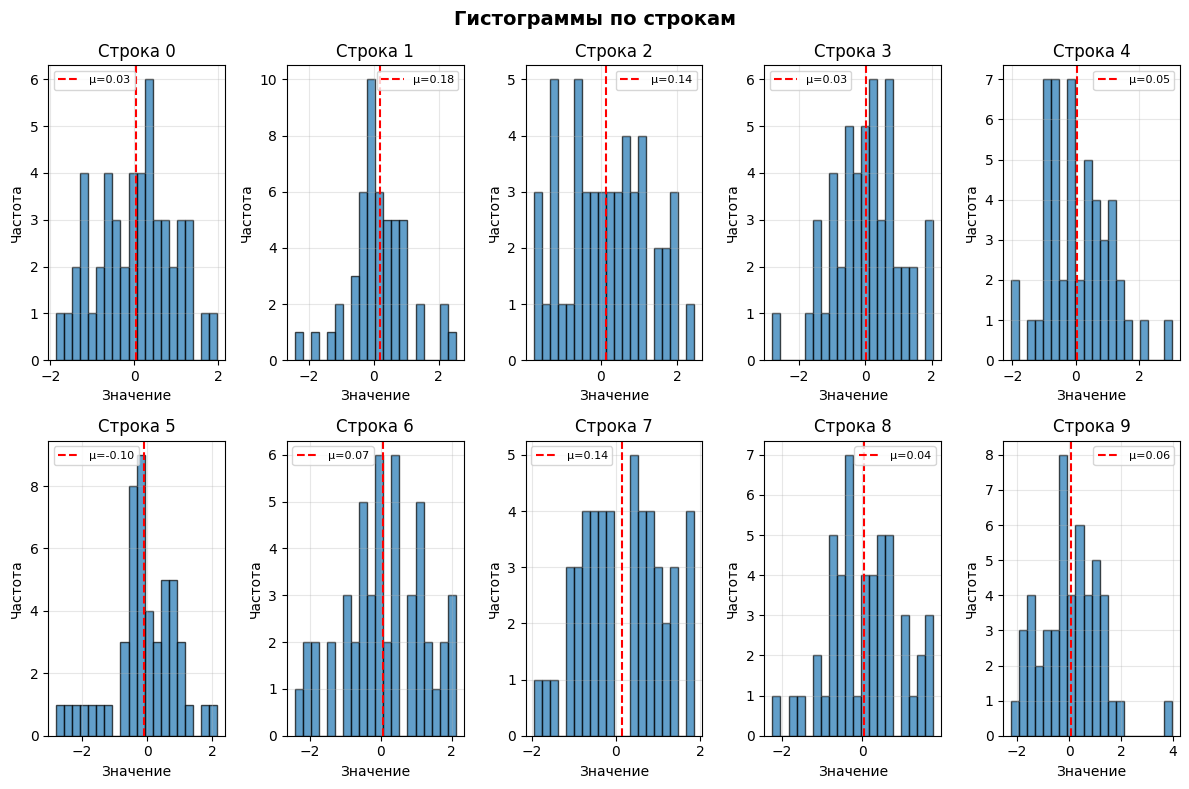

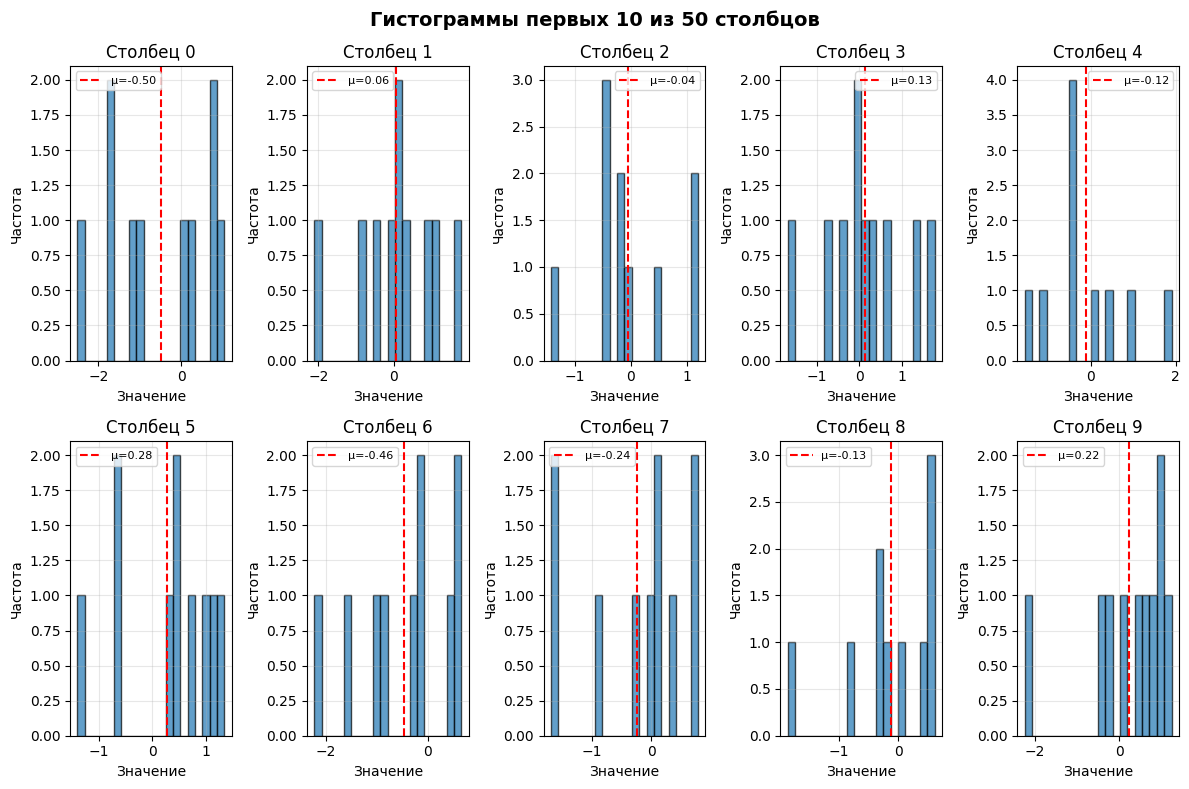

{'matrix': array([[ 1.21821271e-01,  1.12948391e+00,  1.19891788e+00,
          1.85156417e-01, -3.75284950e-01, -6.38730407e-01,
          4.23494354e-01,  7.73400683e-02, -3.43853676e-01,
          4.35968568e-02, -6.20000844e-01,  6.98032034e-01,
         -4.47128565e-01,  1.22450770e+00,  4.03491642e-01,
          5.93578523e-01, -1.09491185e+00,  1.69382433e-01,
          7.40556451e-01, -9.53700602e-01, -2.66218506e-01,
          3.26145467e-02, -1.37311732e+00,  3.15159392e-01,
          8.46160648e-01, -8.59515941e-01,  3.50545979e-01,
         -1.31228341e+00, -3.86955093e-02, -1.61577235e+00,
          1.12141771e+00,  4.08900538e-01, -2.46169559e-02,
         -7.75161619e-01,  1.27375593e+00,  1.96710175e+00,
         -1.85798186e+00,  1.23616403e+00,  1.62765075e+00,
          3.38011697e-01, -1.19926803e+00,  8.63345318e-01,
         -1.80920302e-01, -6.03920628e-01, -1.23005814e+00,
          5.50537496e-01,  7.92806866e-01, -6.23530730e-01,
          5.20576337e-01, -1.1

In [9]:
analyze_matrix_distribution(
    m=10, 
    n=50, 
    mean=0, 
    std=1,
    plot_histograms=True
)

In [10]:
class TestAnalyzeMatrixDistribution(unittest.TestCase):
    def test_matrix_shape(self):
        result = analyze_matrix_distribution(5, 3, seed=42)
        self.assertEqual(result['matrix'].shape, (5, 3))

    def test_statistics_dimensions(self):
        m, n = 10, 7
        result = analyze_matrix_distribution(m, n, seed=123)
        
        self.assertEqual(result['row_stats']['mean'].shape, (m,))
        self.assertEqual(result['row_stats']['var'].shape, (m,))
        self.assertEqual(result['col_stats']['mean'].shape, (n,))
        self.assertEqual(result['col_stats']['var'].shape, (n,))

    def test_variance_close_to_expected(self):
        result = analyze_matrix_distribution(1000, 100, mean=0.0, std=3.0, seed=42)
        
        overall_var = np.var(result['matrix'], ddof=0)
        self.assertAlmostEqual(overall_var, 9.0, delta=0.5)

    def test_reproducibility_with_seed(self):
        result1 = analyze_matrix_distribution(5, 5, seed=999)
        result2 = analyze_matrix_distribution(5, 5, seed=999)
        npt.assert_array_equal(result1['matrix'], result2['matrix'])

    def test_different_seeds_produce_different_matrices(self):
        result1 = analyze_matrix_distribution(5, 5, seed=1)
        result2 = analyze_matrix_distribution(5, 5, seed=2)
        self.assertFalse(np.array_equal(result1['matrix'], result2['matrix']))

    def test_invalid_dimensions(self):
        with self.assertRaises(ValueError):
            analyze_matrix_distribution(0, 5)
        with self.assertRaises(ValueError):
            analyze_matrix_distribution(-3, 4)
        with self.assertRaises(ValueError):
            analyze_matrix_distribution(2.5, 3)

    def test_negative_std(self):
        with self.assertRaises(ValueError):
            analyze_matrix_distribution(5, 5, std=-1.0)

    def test_custom_parameters(self):
        result = analyze_matrix_distribution(3, 4, mean=10.0, std=0.5, seed=42)
        self.assertTrue(np.all(result['matrix'] > 8))
        self.assertTrue(np.all(result['matrix'] < 12))

    def test_return_structure(self):
        result = analyze_matrix_distribution(4, 6)
        self.assertIn('matrix', result)
        self.assertIn('row_stats', result)
        self.assertIn('col_stats', result)
        self.assertIn('mean', result['row_stats'])
        self.assertIn('var', result['row_stats'])
        self.assertIn('mean', result['col_stats'])
        self.assertIn('var', result['col_stats'])

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_custom_parameters (__main__.TestAnalyzeMatrixDistribution.test_custom_parameters) ... ok
test_different_seeds_produce_different_matrices (__main__.TestAnalyzeMatrixDistribution.test_different_seeds_produce_different_matrices) ... ok
test_invalid_dimensions (__main__.TestAnalyzeMatrixDistribution.test_invalid_dimensions) ... ok
test_matrix_shape (__main__.TestAnalyzeMatrixDistribution.test_matrix_shape) ... ok
test_negative_std (__main__.TestAnalyzeMatrixDistribution.test_negative_std) ... ok
test_reproducibility_with_seed (__main__.TestAnalyzeMatrixDistribution.test_reproducibility_with_seed) ... ok
test_return_structure (__main__.TestAnalyzeMatrixDistribution.test_return_structure) ... ok
test_statistics_dimensions (__main__.TestAnalyzeMatrixDistribution.test_statistics_dimensions) ... ok
test_variance_close_to_expected (__main__.TestAnalyzeMatrixDistribution.test_variance_close_to_expected) ... ok
test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
t

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [11]:
def chess(m, n, a, b):
    row_indices = np.arange(m)[:, np.newaxis]
    col_indices = np.arange(n)[np.newaxis, :]

    chess_mask = (row_indices + col_indices) % 2 == 0

    return np.where(chess_mask, a, b)

In [12]:
class TestChessMatrix(unittest.TestCase):
    def test_standard_2x2(self):
        res = chess(2, 2, 1, 0)
        expected = np.array([[1, 0],
                             [0, 1]])
        npt.assert_array_equal(res, expected)

    def test_odd_dimensions_3x3(self):
        res = chess(3, 3, 5, 9)
        expected = np.array([[5, 9, 5],
                             [9, 5, 9],
                             [5, 9, 5]])
        npt.assert_array_equal(res, expected)

    def test_row_vector_1x5(self):
        res = chess(1, 5, 10, 20)
        expected = np.array([[10, 20, 10, 20, 10]])
        npt.assert_array_equal(res, expected)

    def test_column_vector_5x1(self):
        res = chess(5, 1, 10, 20)
        expected = np.array([[10], [20], [10], [20], [10]])
        npt.assert_array_equal(res, expected)

    def test_single_element_1x1(self):
        res = chess(1, 1, 42, 7)
        npt.assert_array_equal(res, np.array([[42]]))

    def test_float_values(self):
        res = chess(4, 4, 0.0, -1.5)
        self.assertEqual(res[0, 0], 0.0)
        self.assertEqual(res[0, 1], -1.5)
        self.assertEqual(res[1, 0], -1.5)
        self.assertEqual(res[1, 1], 0.0)

    def test_pattern_correctness_large(self):
        m, n = 10, 10
        res = chess(m, n, 'A', 'B')
        for i in range(m):
            for j in range(n):
                expected = 'A' if (i + j) % 2 == 0 else 'B'
                self.assertEqual(res[i, j], expected, 
                                 f"Несоответствие в ячейке ({i},{j})")

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_custom_parameters (__main__.TestAnalyzeMatrixDistribution.test_custom_parameters) ... ok
test_different_seeds_produce_different_matrices (__main__.TestAnalyzeMatrixDistribution.test_different_seeds_produce_different_matrices) ... ok
test_invalid_dimensions (__main__.TestAnalyzeMatrixDistribution.test_invalid_dimensions) ... ok
test_matrix_shape (__main__.TestAnalyzeMatrixDistribution.test_matrix_shape) ... ok
test_negative_std (__main__.TestAnalyzeMatrixDistribution.test_negative_std) ... ok
test_reproducibility_with_seed (__main__.TestAnalyzeMatrixDistribution.test_reproducibility_with_seed) ... ok
test_return_structure (__main__.TestAnalyzeMatrixDistribution.test_return_structure) ... ok
test_statistics_dimensions (__main__.TestAnalyzeMatrixDistribution.test_statistics_dimensions) ... ok
test_variance_close_to_expected (__main__.TestAnalyzeMatrixDistribution.test_variance_close_to_expected) ... ok
test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
t

<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [13]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    if any(x <= 0 for x in (a, b, m, n)):
        raise ValueError()
    
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    
    x_start = max(0, (n - a) // 2)
    x_end = min(n, x_start + a)
    y_start = max(0, (m - b) // 2)
    y_end = min(m, y_start + b)
    
    if x_start < x_end and y_start < y_end:
        img[y_start:y_end, x_start:x_end] = rectangle_color
        
    return img

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    if any(x <= 0 for x in (a, b, m, n)):
        raise ValueError()
    
    img = np.full((m, n, 3), background_color, dtype=np.uint8)
    
    x0, y0 = n / 2.0, m / 2.0
    
    y, x = np.ogrid[0:m, 0:n]
    
    mask = ((x - x0) ** 2) / (a ** 2) + ((y - y0) ** 2) / (b ** 2) <= 1.0
    
    img[mask] = ellipse_color
        
    return img

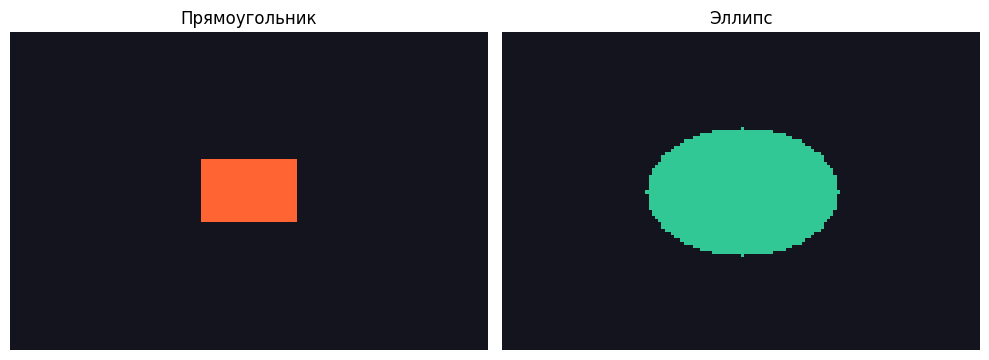

In [14]:
img_rect = draw_rectangle(30, 20, 100, 150, (255, 100, 50), (20, 20, 30))
img_ell = draw_ellipse(30, 20, 100, 150, (50, 200, 150), (20, 20, 30))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rect)
plt.title("Прямоугольник")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_ell)
plt.title("Эллипс")
plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
class TestShapeDrawing(unittest.TestCase):
    def test_rectangle_output_shape(self):
        m, n = 60, 80
        img = draw_rectangle(20, 30, m, n, (255, 0, 0), (0, 0, 0))
        self.assertEqual(img.shape, (m, n, 3))
        self.assertEqual(img.dtype, np.uint8)

    def test_rectangle_exact_dimensions(self):
        a, b, m, n = 14, 22, 100, 100
        img = draw_rectangle(a, b, m, n, (200, 150, 100), (10, 10, 10))
        mask_rect = np.all(img == np.array([200, 150, 100]), axis=-1)
        self.assertEqual(np.sum(mask_rect), a * b)

    def test_rectangle_centering(self):
        m, n, a, b = 100, 100, 20, 20
        img = draw_rectangle(a, b, m, n, (0, 255, 0), (0, 0, 0))
        self.assertTrue(np.array_equal(img[50, 50], [0, 255, 0]))
        self.assertTrue(np.array_equal(img[0, 0], [0, 0, 0]))

    def test_ellipse_output_shape(self):
        m, n = 50, 70
        img = draw_ellipse(15, 10, m, n, (0, 0, 255), (255, 255, 255))
        self.assertEqual(img.shape, (m, n, 3))
        self.assertEqual(img.dtype, np.uint8)

    def test_ellipse_area_approximation(self):
        a, b, m, n = 30.0, 20.0, 100, 100
        img = draw_ellipse(a, b, m, n, (0, 200, 0), (100, 100, 100))
        mask_ell = np.all(img == np.array([0, 200, 0]), axis=-1)
        actual_pixels = np.sum(mask_ell)
        theoretical_area = np.pi * a * b
        self.assertAlmostEqual(actual_pixels, theoretical_area, delta=0.05 * theoretical_area)

    def test_ellipse_boundary_equation(self):
        a, b, m, n = 50.0, 30.0, 100, 100
        img = draw_ellipse(a, b, m, n, (50, 50, 50), (200, 200, 200))
        self.assertTrue(np.array_equal(img[50, 50], [50, 50, 50]))
        self.assertTrue(np.array_equal(img[0, 0], [200, 200, 200]))

    def test_invalid_inputs(self):
        with self.assertRaises(ValueError):
            draw_rectangle(-5, 10, 50, 50, (1, 1, 1), (0, 0, 0))
        with self.assertRaises(ValueError):
            draw_ellipse(10, -2, 50, 50, (1, 1, 1), (0, 0, 0))
        with self.assertRaises(ValueError):
            draw_rectangle(5, 5, 0, 50, (1, 1, 1), (0, 0, 0))

    def test_color_preservation(self):
        bg = (12, 34, 56)
        fg = (255, 128, 0)
        img = draw_rectangle(10, 10, 30, 30, fg, bg)
        npt.assert_array_equal(img[0, 0], bg)
        npt.assert_array_equal(img[15, 15], fg)

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_custom_parameters (__main__.TestAnalyzeMatrixDistribution.test_custom_parameters) ... ok
test_different_seeds_produce_different_matrices (__main__.TestAnalyzeMatrixDistribution.test_different_seeds_produce_different_matrices) ... ok
test_invalid_dimensions (__main__.TestAnalyzeMatrixDistribution.test_invalid_dimensions) ... ok
test_matrix_shape (__main__.TestAnalyzeMatrixDistribution.test_matrix_shape) ... ok
test_negative_std (__main__.TestAnalyzeMatrixDistribution.test_negative_std) ... ok
test_reproducibility_with_seed (__main__.TestAnalyzeMatrixDistribution.test_reproducibility_with_seed) ... ok
test_return_structure (__main__.TestAnalyzeMatrixDistribution.test_return_structure) ... ok
test_statistics_dimensions (__main__.TestAnalyzeMatrixDistribution.test_statistics_dimensions) ... ok
test_variance_close_to_expected (__main__.TestAnalyzeMatrixDistribution.test_variance_close_to_expected) ... ok
test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
t

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [16]:
def analyze_time_series(
    series: Union[List[float], np.ndarray], 
    window_size: int
):
    series = np.asarray(series, dtype=float).flatten()
    n = len(series)
    
    if n == 0:
        raise ValueError("Временной ряд не может быть пустым.")
    if not isinstance(window_size, int) or window_size <= 0:
        raise ValueError("Размер окна должен быть положительным целым числом.")
    if window_size > n:
        raise ValueError("Размер окна не может превышать длину ряда.")

    mean_val = np.mean(series)
    variance_val = np.var(series, ddof=0)
    std_val = np.sqrt(variance_val)

    local_maxima = []
    local_minima = []
    
    for i in range(1, n - 1):
        if series[i] > series[i-1] and series[i] > series[i+1]:
            local_maxima.append(i)
        elif series[i] < series[i-1] and series[i] < series[i+1]:
            local_minima.append(i)

    if window_size == n:
        moving_avg = np.full(n, mean_val)
    else:
        half = window_size // 2
        moving_avg = np.array([
            np.mean(series[max(0, i - half) : min(n, i + half + 1)]) 
            for i in range(n)
        ])

    return {
        'mean': mean_val,
        'variance': variance_val,
        'std': std_val,
        'local_maxima': local_maxima,
        'local_minima': local_minima,
        'moving_avg': moving_avg
    }

In [17]:
class TestTimeSeriesAnalysis(unittest.TestCase):
    def test_basic_statistics(self):
        series = [1, 2, 3, 4, 5]
        result = analyze_time_series(series, window_size=3)
        
        self.assertAlmostEqual(result['mean'], 3.0)
        self.assertAlmostEqual(result['variance'], 2.0)
        self.assertAlmostEqual(result['std'], np.sqrt(2.0))

    def test_local_extrema_simple(self):
        series = [1, 3, 2, 4, 1]
        result = analyze_time_series(series, window_size=3)
        
        self.assertEqual(result['local_maxima'], [1, 3])
        self.assertEqual(result['local_minima'], [2])

    def test_no_extrema_monotonic(self):
        series = [1, 2, 3, 4, 5, 6]
        result = analyze_time_series(series, window_size=3)
        
        self.assertEqual(result['local_maxima'], [])
        self.assertEqual(result['local_minima'], [])

    def test_moving_average_odd_window(self):
        series = [1, 2, 3, 4, 5]
        result = analyze_time_series(series, window_size=3)
        
        expected = np.array([1.5, 2.0, 3.0, 4.0, 4.5])
        npt.assert_array_almost_equal(result['moving_avg'], expected)
        self.assertEqual(len(result['moving_avg']), len(series))

    def test_moving_average_even_window(self):
        series = [1, 2, 3, 4, 5, 6]
        result = analyze_time_series(series, window_size=4) 
        
        expected = np.array([2.0, 2.5, 3.0, 4.0, 4.5, 5.0])
        npt.assert_array_almost_equal(result['moving_avg'], expected)

    def test_moving_average_window_equals_length(self):
        series = [10, 20, 30]
        result = analyze_time_series(series, window_size=3)
        
        expected = np.array([20.0, 20.0, 20.0])
        npt.assert_array_almost_equal(result['moving_avg'], expected)
        self.assertEqual(len(result['moving_avg']), len(series))

    def test_moving_average_window_size_one(self):
        series = [1, 2, 3, 4]
        result = analyze_time_series(series, window_size=1)
        
        npt.assert_array_almost_equal(result['moving_avg'], series)

    def test_flat_series(self):
        series = [5.0] * 10
        result = analyze_time_series(series, window_size=3)
        
        self.assertAlmostEqual(result['mean'], 5.0)
        self.assertAlmostEqual(result['variance'], 0.0)
        self.assertAlmostEqual(result['std'], 0.0)
        self.assertEqual(result['local_maxima'], [])
        self.assertEqual(result['local_minima'], [])
        npt.assert_array_almost_equal(result['moving_avg'], np.full(10, 5.0))

    def test_invalid_inputs(self):
        with self.assertRaises(ValueError):
            analyze_time_series([], window_size=3)
        with self.assertRaises(ValueError):
            analyze_time_series([1, 2, 3], window_size=0)
        with self.assertRaises(ValueError):
            analyze_time_series([1, 2], window_size=5)

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_custom_parameters (__main__.TestAnalyzeMatrixDistribution.test_custom_parameters) ... ok
test_different_seeds_produce_different_matrices (__main__.TestAnalyzeMatrixDistribution.test_different_seeds_produce_different_matrices) ... ok
test_invalid_dimensions (__main__.TestAnalyzeMatrixDistribution.test_invalid_dimensions) ... ok
test_matrix_shape (__main__.TestAnalyzeMatrixDistribution.test_matrix_shape) ... ok
test_negative_std (__main__.TestAnalyzeMatrixDistribution.test_negative_std) ... ok
test_reproducibility_with_seed (__main__.TestAnalyzeMatrixDistribution.test_reproducibility_with_seed) ... ok
test_return_structure (__main__.TestAnalyzeMatrixDistribution.test_return_structure) ... ok
test_statistics_dimensions (__main__.TestAnalyzeMatrixDistribution.test_statistics_dimensions) ... ok
test_variance_close_to_expected (__main__.TestAnalyzeMatrixDistribution.test_variance_close_to_expected) ... ok
test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
t

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [18]:
def one_hot_encode(
    labels: Union[List[int], np.ndarray]
):
    labels = np.asarray(labels, dtype=int)
    if labels.size == 0:
        raise ValueError("Входной вектор не может быть пустым.")
    if labels.ndim != 1:
        raise ValueError("Входные данные должны представлять собой одномерный вектор.")
    if np.any(labels < 0):
        raise ValueError("Метки классов должны быть неотрицательными целыми числами.")
        
    num_classes = int(np.max(labels)) + 1
        
    one_hot = np.zeros((labels.size, num_classes), dtype=int)
    one_hot[np.arange(labels.size), labels] = 1
    
    return one_hot

In [19]:
class TestOneHotEncode(unittest.TestCase):
    def test_example_from_task(self):
        labels = [0, 2, 3, 0]
        expected = [[1, 0, 0, 0],
                    [0, 0, 1, 0],
                    [0, 0, 0, 1],
                    [1, 0, 0, 0]]
        npt.assert_array_equal(one_hot_encode(labels), expected)

    def test_single_element(self):
        labels = [4]
        expected = [[0, 0, 0, 0, 1]]
        npt.assert_array_equal(one_hot_encode(labels), expected)

    def test_identical_labels(self):
        labels = [1, 1, 1]
        expected = [[0, 1],
                    [0, 1],
                    [0, 1]]
        npt.assert_array_equal(one_hot_encode(labels), expected)

    def test_sparse_labels(self):
        labels = [0, 5, 2]
        result = one_hot_encode(labels)
        self.assertEqual(result.shape, (3, 6))
        self.assertEqual(result[0, 0], 1)
        self.assertEqual(result[1, 5], 1)
        self.assertEqual(result[2, 2], 1)

    def test_negative_labels(self):
        with self.assertRaises(ValueError):
            one_hot_encode([-1, 0, 1])

    def test_empty_input(self):
        with self.assertRaises(ValueError):
            one_hot_encode([])

    def test_2d_input_raises(self):
        with self.assertRaises(ValueError):
            one_hot_encode([[0, 1], [2, 3]])

    def test_output_dtype(self):
        result = one_hot_encode([0, 1, 2])
        self.assertEqual(result.dtype, np.int64)

unittest.main(argv=["first-arg-is-ignored"], exit=False, verbosity=2)

test_custom_parameters (__main__.TestAnalyzeMatrixDistribution.test_custom_parameters) ... ok
test_different_seeds_produce_different_matrices (__main__.TestAnalyzeMatrixDistribution.test_different_seeds_produce_different_matrices) ... ok
test_invalid_dimensions (__main__.TestAnalyzeMatrixDistribution.test_invalid_dimensions) ... ok
test_matrix_shape (__main__.TestAnalyzeMatrixDistribution.test_matrix_shape) ... ok
test_negative_std (__main__.TestAnalyzeMatrixDistribution.test_negative_std) ... ok
test_reproducibility_with_seed (__main__.TestAnalyzeMatrixDistribution.test_reproducibility_with_seed) ... ok
test_return_structure (__main__.TestAnalyzeMatrixDistribution.test_return_structure) ... ok
test_statistics_dimensions (__main__.TestAnalyzeMatrixDistribution.test_statistics_dimensions) ... ok
test_variance_close_to_expected (__main__.TestAnalyzeMatrixDistribution.test_variance_close_to_expected) ... ok
test_all_above_threshold (__main__.TestBinarize.test_all_above_threshold) ... ok
t